In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import onnxruntime as ort

from numpy.lib.stride_tricks import sliding_window_view
from matplotlib import pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from scipy.stats import hmean
from tqdm.notebook import tqdm

from create_rollover_detection_15m import train_target

In [2]:
seq_len = 50
pred_distance = 0

model = ort.InferenceSession(f"outputs/checkpoints/model_seq_{seq_len}_pred_{pred_distance}_15m.onnx")

In [3]:
feature_name_list = ['boom_angle(deg)', 'ref_swing_angle(deg)', 'load_weight(ton)', 'engine_speed(rpm)',
                     'body_angle_x(deg)', 'body_angle_y(deg)']
target_name = 'roll_over_state'

In [4]:
file_name_list = ['data20251222-133102_swing_0_boom_55_1.csv',
                  'data20251222-133551_swing_0_boom_55_2.csv',
                  'data20251222-133904_swing_0_boom_55_3.csv',
                  'data20251222-134228_swing_0_boom_55_4.csv',
                  'data20251222-135532_swing_0_boom_45_1.csv',
                  'data20251222-135826_swing_0_boom_45_2.csv',
                  'data20251222-140154_swing_0_boom_45_3.csv',
                  'data20251222-140457_swing_0_boom_45_4.csv',
                  'data20251222-141357_swing_0_boom_35_1.csv',
                  'data20251222-141645_swing_0_boom_35_2.csv',
                  'data20251222-141951_swing_0_boom_35_3.csv',
                  'data20251222-142245_swing_0_boom_35_4.csv',
                  'data20251223-143719_swing_0_boom_35_5.csv',
                  'data20251223-144010_swing_0_boom_35_6.csv']

data_list = []

for file_name in file_name_list:
    path = os.path.join('data/on-road_test_15meter', file_name)
    data = pd.read_csv(path)
    data = data.iloc[:, 1:]
    data['ref_swing_angle(deg)'] = 0
    data_list.append(data)

data = pd.concat(data_list, axis=0)
data.shape

(18676, 21)

In [5]:
swing_0_data = data.copy()
swing_0_data = swing_0_data[swing_0_data['boom_angle(deg)'] > 1]
swing_0_data.reset_index(drop=True, inplace=True)
swing_0_data

,time(sec),boom_length(m),boom_angle(deg),load_weight(ton),engine_speed(rpm),wind_speed(m/s),swing_angle(deg),body_angle_x(deg),body_angle_y(deg),load_cell_left_1,...,load_cell_left_3,load_cell_right_1,load_cell_right_2,load_cell_right_3,forward_load_ratio,detection,ref_swing_angle(deg),load_ratio,roll_over_state,pred
0,0.101,15.029,55.263,2.675,748.0,-0.598,5.625,-0.37,0.12,1.16,...,1.38,4.060,0.0,2.43,0.15611,0.0,0,NaN,NaN,NaN
1,0.201,15.029,55.263,2.681,748.0,-0.598,5.625,-0.37,0.11,1.15,...,1.38,4.060,0.0,2.43,0.15518,0.0,0,NaN,NaN,NaN
2,0.302,15.029,55.263,2.681,748.0,-0.598,5.625,-0.37,0.11,1.15,...,1.38,4.060,0.0,2.42,0.15646,0.0,0,NaN,NaN,NaN
3,0.402,15.030,55.268,2.681,748.0,-0.598,5.625,-0.37,0.11,1.16,...,1.38,4.060,0.0,2.42,0.15739,0.0,0,NaN,NaN,NaN
4,0.503,15.030,55.268,2.681,748.0,-0.598,5.625,-0.36,0.11,1.16,...,1.38,4.060,0.0,2.42,0.15739,0.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18650,170.285,15.058,34.983,3.681,768.0,-0.598,0.000,-0.40,0.34,1.33,...,3.55,34.454,0.0,7.68,NaN,0.0,0,-0.28901,0.0,0.0
18651,170.386,15.058,34.983,3.681,768.0,-0.598,0.000,-0.34,0.31,1.32,...,3.55,34.454,0.0,7.68,NaN,0.0,0,-0.29091,0.0,0.0
18652,170.486,15.058,34.983,3.672,772.0,-0.598,0.000,-0.32,0.30,1.32,...,3.55,34.454,0.0,7.68,NaN,0.0,0,-0.29091,0.0,0.0
18653,170.587,15.058,34.983,3.672,772.0,-0.598,0.000,-0.34,0.32,1.32,...,3.55,34.454,0.0,7.68,NaN,0.0,0,-0.29091,0.0,0.0


In [6]:
load_cell_name_list = ['load_cell_left_1', 'load_cell_left_2', 'load_cell_left_3',
                       'load_cell_right_1', 'load_cell_right_2', 'load_cell_right_3']
load_cell_name_list = np.array(load_cell_name_list)

In [7]:
len_window = 5

for load_cell_name in load_cell_name_list:
    load = swing_0_data[load_cell_name].to_numpy()
    filtered_load = np.median(sliding_window_view(load, window_shape=len_window), axis=1)
    filtered_load = np.insert(filtered_load, 0, [0]*(len_window-1))
    swing_0_data[load_cell_name] = filtered_load

swing_0_data

,time(sec),boom_length(m),boom_angle(deg),load_weight(ton),engine_speed(rpm),wind_speed(m/s),swing_angle(deg),body_angle_x(deg),body_angle_y(deg),load_cell_left_1,...,load_cell_left_3,load_cell_right_1,load_cell_right_2,load_cell_right_3,forward_load_ratio,detection,ref_swing_angle(deg),load_ratio,roll_over_state,pred
0,0.101,15.029,55.263,2.675,748.0,-0.598,5.625,-0.37,0.12,0.00,...,0.00,0.000,0.0,0.00,0.15611,0.0,0,NaN,NaN,NaN
1,0.201,15.029,55.263,2.681,748.0,-0.598,5.625,-0.37,0.11,0.00,...,0.00,0.000,0.0,0.00,0.15518,0.0,0,NaN,NaN,NaN
2,0.302,15.029,55.263,2.681,748.0,-0.598,5.625,-0.37,0.11,0.00,...,0.00,0.000,0.0,0.00,0.15646,0.0,0,NaN,NaN,NaN
3,0.402,15.030,55.268,2.681,748.0,-0.598,5.625,-0.37,0.11,0.00,...,0.00,0.000,0.0,0.00,0.15739,0.0,0,NaN,NaN,NaN
4,0.503,15.030,55.268,2.681,748.0,-0.598,5.625,-0.36,0.11,1.16,...,1.38,4.060,0.0,2.42,0.15739,0.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18650,170.285,15.058,34.983,3.681,768.0,-0.598,0.000,-0.40,0.34,1.33,...,3.87,34.454,0.0,7.68,NaN,0.0,0,-0.28901,0.0,0.0
18651,170.386,15.058,34.983,3.681,768.0,-0.598,0.000,-0.34,0.31,1.33,...,3.87,34.454,0.0,7.68,NaN,0.0,0,-0.29091,0.0,0.0
18652,170.486,15.058,34.983,3.672,772.0,-0.598,0.000,-0.32,0.30,1.33,...,3.55,34.454,0.0,7.68,NaN,0.0,0,-0.29091,0.0,0.0
18653,170.587,15.058,34.983,3.672,772.0,-0.598,0.000,-0.34,0.32,1.32,...,3.55,34.454,0.0,7.68,NaN,0.0,0,-0.29091,0.0,0.0


In [8]:
load_cell_name_list = np.array(load_cell_name_list)

left_diff = np.abs(swing_0_data[load_cell_name_list[0]] - swing_0_data[load_cell_name_list[2]])
left_diff = left_diff.to_numpy()

right_diff = np.abs(swing_0_data[load_cell_name_list[3]] - swing_0_data[load_cell_name_list[5]])
right_diff = right_diff.to_numpy()

left_sum = swing_0_data[load_cell_name_list[0]] + swing_0_data[load_cell_name_list[2]]
left_sum = left_sum.to_numpy()

right_sum = swing_0_data[load_cell_name_list[3]] + swing_0_data[load_cell_name_list[5]]
right_sum = right_sum.to_numpy()

left_ratio = left_diff/(left_sum+0.001)
right_ratio = right_diff/(right_sum+0.001)

load_ratio = 1-hmean([left_ratio, right_ratio], axis=0)

roll_over_state_int = []

for i in load_ratio:
    if i >= 0.3:
        roll_over_state_int.append(0)
    if 0.3 > i >= 0.2:
        roll_over_state_int.append(1)
    if i < 0.2:
        roll_over_state_int.append(2)

swing_0_data['load_ratio'] = load_ratio
swing_0_data[target_name] = np.array(roll_over_state_int)

In [9]:
feature_name_list = ['boom_angle(deg)', 'ref_swing_angle(deg)', 'load_weight(ton)', 'engine_speed(rpm)',
                     'body_angle_x(deg)', 'body_angle_y(deg)']
target_name = 'roll_over_state'

swing_0_dataset = swing_0_data[feature_name_list + [target_name]]

In [10]:
file_name_list = ['data20251222-152221_swing_90_boom_55_1.csv',
                  'data20251222-152557_swing_90_boom_55_2.csv',
                  'data20251222-152847_swing_90_boom_55_3.csv',
                  'data20251222-153142_swing_90_boom_55_4.csv']

data_list = []

for file_name in file_name_list:
    path = os.path.join('data/on-road_test_15meter', file_name)
    data = pd.read_csv(path)
    data = data.iloc[:, 1:]
    data['ref_swing_angle(deg)'] = 90
    data_list.append(data)

data = pd.concat(data_list, axis=0)

In [11]:
swing_90_data = data.copy()
swing_90_data = swing_90_data[swing_90_data['boom_angle(deg)'] > 1]
swing_90_data.reset_index(drop=True, inplace=True)
swing_90_data

,time(sec),boom_length(m),boom_angle(deg),load_weight(ton),engine_speed(rpm),wind_speed(m/s),swing_angle(deg),body_angle_x(deg),body_angle_y(deg),load_cell_left_1,load_cell_left_2,load_cell_left_3,load_cell_right_1,load_cell_right_2,load_cell_right_3,forward_load_ratio,detection,ref_swing_angle(deg)
0,0.202,15.010,55.203,3.200,748.0,-0.598,25.25,-0.18,0.70,6.79,0.00,2.04,1.36,0.0,0.98,0.45918,0.0,90
1,0.302,15.010,55.203,3.194,748.0,-0.598,25.25,-0.18,0.70,6.79,0.00,2.04,1.36,0.0,0.98,0.45918,0.0,90
2,0.403,15.010,55.203,3.194,748.0,-0.598,25.25,-0.19,0.69,6.79,0.00,2.04,1.36,0.0,0.98,0.45918,0.0,90
3,0.503,15.010,55.203,3.194,748.0,-0.598,25.25,-0.18,0.69,6.79,0.00,2.04,1.36,0.0,0.98,0.45918,0.0,90
4,0.604,15.010,55.203,3.194,748.0,-0.598,25.25,-0.18,0.69,6.79,0.00,2.04,1.36,0.0,0.98,0.45918,0.0,90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4374,101.098,15.013,55.214,2.869,748.0,-0.598,25.25,-0.14,0.68,8.69,0.17,2.07,0.00,0.0,1.04,0.47280,0.0,90
4375,101.199,15.013,55.214,2.872,748.0,-0.598,25.25,-0.14,0.68,8.69,0.18,2.08,0.00,0.0,1.04,0.47155,0.0,90
4376,101.299,15.013,55.214,2.872,748.0,-0.598,25.25,-0.14,0.68,8.70,0.18,2.07,0.00,0.0,1.04,0.47325,0.0,90
4377,101.400,15.012,55.209,2.856,748.0,-0.598,25.25,-0.14,0.69,8.69,0.17,2.08,0.00,0.0,1.04,0.47155,0.0,90


In [12]:
load_cell_name_list = np.array(load_cell_name_list)

left_diff = np.abs(swing_90_data[load_cell_name_list[0]] - swing_90_data[load_cell_name_list[3]])
left_diff = left_diff.to_numpy()

right_diff = np.abs(swing_90_data[load_cell_name_list[2]] - swing_90_data[load_cell_name_list[5]])
right_diff = right_diff.to_numpy()

left_sum = swing_90_data[load_cell_name_list[0]] + swing_90_data[load_cell_name_list[3]]
left_sum = left_sum.to_numpy()

right_sum = swing_90_data[load_cell_name_list[2]] + swing_90_data[load_cell_name_list[5]]
right_sum = right_sum.to_numpy()

left_ratio = left_diff/(left_sum+0.001)
right_ratio = right_diff/(right_sum+0.001)

load_ratio = hmean([left_ratio, right_ratio], axis=0)
roll_over_state_1 = (load_ratio < 0.4)*1
roll_over_state_2 = (load_ratio < 0.35)*1

roll_over_state_int = []

for i in load_ratio:
    if i >= 0.4:
        roll_over_state_int.append(0)
    if 0.4 > i >= 0.35:
        roll_over_state_int.append(1)
    if i < 0.35:
        roll_over_state_int.append(2)

swing_90_data['load_ratio'] = load_ratio
swing_90_data[target_name] = np.array(roll_over_state_int)

In [13]:
swing_90_dataset = swing_90_data[feature_name_list + [target_name]]

In [14]:
dataset = pd.concat([swing_0_dataset, swing_90_dataset], axis=0)
dataset.reset_index(inplace=True, drop=True)
dataset

,boom_angle(deg),ref_swing_angle(deg),load_weight(ton),engine_speed(rpm),body_angle_x(deg),body_angle_y(deg),roll_over_state
0,55.263,0,2.675,748.0,-0.37,0.12,0
1,55.263,0,2.681,748.0,-0.37,0.11,0
2,55.263,0,2.681,748.0,-0.37,0.11,0
3,55.268,0,2.681,748.0,-0.37,0.11,0
4,55.268,0,2.681,748.0,-0.36,0.11,0
...,...,...,...,...,...,...,...
23029,55.214,90,2.869,748.0,-0.14,0.68,0
23030,55.214,90,2.872,748.0,-0.14,0.68,0
23031,55.214,90,2.872,748.0,-0.14,0.68,0
23032,55.209,90,2.856,748.0,-0.14,0.69,0


In [15]:
dataset_arr = dataset.to_numpy()

feature = dataset_arr[:, 0:len(feature_name_list)]
target = dataset_arr[:, len(feature_name_list)]

In [25]:
input_buf = np.zeros(shape=(1, seq_len, len(feature_name_list)), dtype=np.float32)
pred_list = []

for input_sig in tqdm(feature):
    input_buf = np.roll(a=input_buf, shift=-1, axis=1)
    input_buf[0, -1, :] = input_sig

    pred = model.run(output_names=None, input_feed={'input': input_buf})
    pred = np.argmax(np.squeeze(pred))
    pred_list.append(pred)

pred_arr = np.array(pred_list)

  0%|          | 0/23034 [00:00<?, ?it/s]

<Axes: >

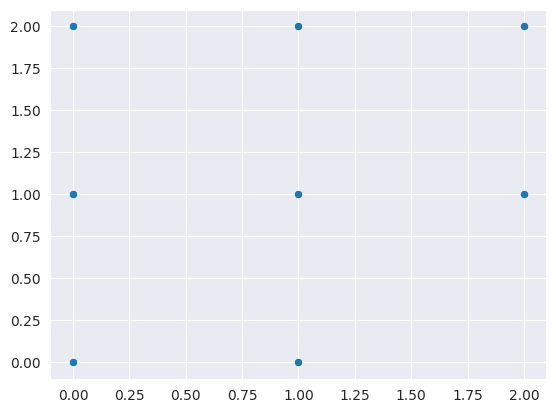

In [27]:
sns.scatterplot(x=target, y=pred_arr)

In [29]:
pred_df = pd.DataFrame(pred_arr, columns=['prediction'])
target_df = pd.DataFrame(target, columns=['target'])

temp = pd.concat([pred_df, target_df], axis=1)
temp

,prediction,target
0,2,0.00000
1,2,0.00000
2,2,0.00000
3,0,0.00000
4,0,0.00000
...,...,...
23029,0,0.00000
23030,0,0.00000
23031,0,0.00000
23032,0,0.00000


In [30]:
target_string = []

for sig in target:
    if sig == 0:
        target_string.append('safe')

    if sig == 1:
        target_string.append('unsafe_1')

    if sig == 2:
        target_string.append('unsafe_2')

result_df = pd.concat([pd.DataFrame(pred_arr, columns=['prediction']),
                       pd.DataFrame(target_string, columns=['target'])], axis=1)

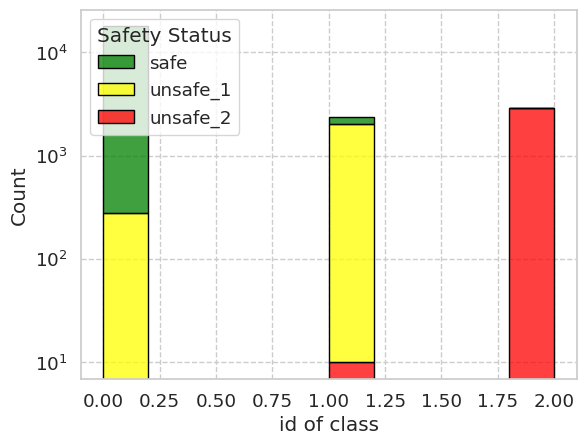

In [32]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

custom_color = {'safe': 'green', 'unsafe_1': 'yellow', 'unsafe_2': 'red'}

ax = sns.histplot(data=result_df, x='prediction', hue='target', bins=10, multiple='stack', edgecolor='black', palette=custom_color)

plt.xlabel('id of class')
plt.yscale('log')

ax.legend_.set_title('Safety Status')

Best Threshold: 0.920
Best F1 Score: 0.9568


Text(0, 0.5, 'Score')

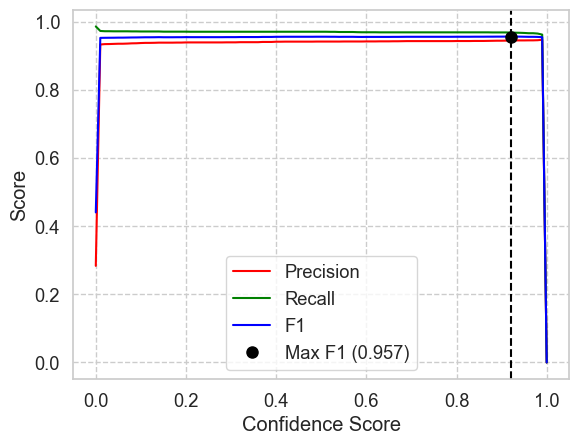

In [65]:
thr_val_arr = np.arange(0.0, 1.01, 0.01)

precision_arr = []
recall_arr = []
f1_arr = []

for thr_val in thr_val_arr:
    pred_binary = np.where(pred_arr > thr_val, 1, 0)
    precision = precision_score(target, pred_binary, zero_division=0)
    recall = recall_score(target, pred_binary, zero_division=0)
    f1 = f1_score(target, pred_binary, zero_division=0)

    precision_arr.append(precision)
    recall_arr.append(recall)
    f1_arr.append(f1)

precision_arr = np.array(precision_arr)
recall_arr = np.array(recall_arr)
f1_arr = np.array(f1_arr)

sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

sns.lineplot(x=thr_val_arr, y=precision_arr, color='red', label='Precision')
sns.lineplot(x=thr_val_arr, y=recall_arr, color='green', label='Recall')
sns.lineplot(x=thr_val_arr, y=f1_arr, color='blue', label='F1')

best_f1_index = np.argmax(f1_arr)

best_threshold = thr_val_arr[best_f1_index]
best_f1_score = f1_arr[best_f1_index]

print(f"Best Threshold: {best_threshold:.3f}")
print(f"Best F1 Score: {best_f1_score:.4f}")

plt.axvline(x=best_threshold, color='black', linestyle='--')

plt.plot(best_threshold, best_f1_score, 'o', color='black', markersize=8,
         markeredgecolor='black', label=f'Max F1 ({best_f1_score:.3f})')

plt.legend()

plt.xlabel('Confidence Score')
plt.ylabel('Score')

([<matplotlib.axis.YTick at 0x2963d47f3d0>,
 [Text(0, 0.5, 'Safe(0)'), Text(0, 1.5, 'Unsafe(1)')])

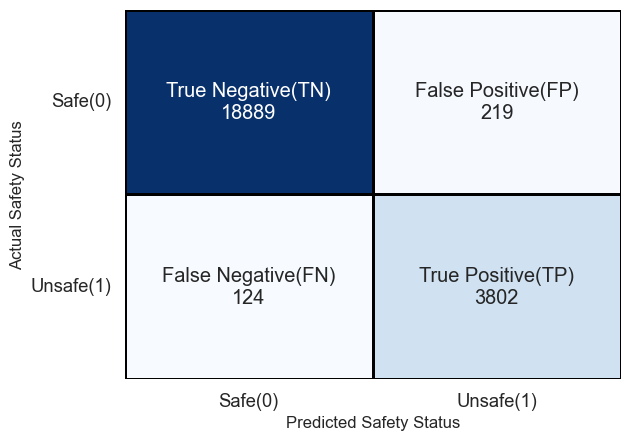

In [66]:
pred_binary = np.where(pred_arr > 0.92, 1, 0)

cm = confusion_matrix(target, pred_binary)

labels = np.array([[f'True Negative(TN)\n{cm[0, 0]}', f'False Positive(FP)\n{cm[0, 1]}'],
                   [f'False Negative(FN)\n{cm[1, 0]}', f'True Positive(TP)\n{cm[1, 1]}']])

sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False, linecolor='black', linewidths=1)

plt.ylabel('Actual Safety Status', fontsize=12)
plt.xlabel('Predicted Safety Status', fontsize=12)

plt.xticks([0.5, 1.5], ['Safe(0)', 'Unsafe(1)'])
plt.yticks([0.5, 1.5], ['Safe(0)', 'Unsafe(1)'], rotation=0, va='center')

In [67]:
print(precision_score(target, pred_binary))
print(recall_score(target, pred_binary))
print(f1_score(target, pred_binary))

0.9455359363342453
0.9684156902699949
0.9568390587643136


In [194]:
# file_name_list = ['data20251222-133102_swing_0_boom_55_1.csv',
#                   'data20251222-133551_swing_0_boom_55_2.csv',
#                   'data20251222-133904_swing_0_boom_55_3.csv',
#                   'data20251222-134228_swing_0_boom_55_4.csv',
#                   'data20251222-135532_swing_0_boom_45_1.csv',
#                   'data20251222-135826_swing_0_boom_45_2.csv',
#                   'data20251222-140154_swing_0_boom_45_3.csv',
#                   'data20251222-140457_swing_0_boom_45_4.csv',
#                   'data20251222-141357_swing_0_boom_35_1.csv',
#                   'data20251222-141645_swing_0_boom_35_2.csv',
#                   'data20251222-141951_swing_0_boom_35_3.csv',
#                   'data20251222-142245_swing_0_boom_35_4.csv',
#                   'data20251223-143719_swing_0_boom_35_5.csv',
#                   'data20251223-144010_swing_0_boom_35_6.csv']
# file_name = file_name_list[-1]

file_name = 'data20251222-152557_swing_90_boom_55_2.csv'
path = os.path.join('data/on-road_test_15meter', file_name)
data = pd.read_csv(path)
data['ref_swing_angle(deg)'] = 90

data_sorted = data.copy()
data_sorted = data_sorted[data_sorted['boom_angle(deg)'] > 1]
data_sorted = data_sorted.iloc[:, 1:]
data_sorted.reset_index(drop=True, inplace=True)
data_sorted

,time(sec),boom_length(m),boom_angle(deg),load_weight(ton),engine_speed(rpm),wind_speed(m/s),swing_angle(deg),body_angle_x(deg),body_angle_y(deg),load_cell_left_1,load_cell_left_2,load_cell_left_3,load_cell_right_1,load_cell_right_2,load_cell_right_3,forward_load_ratio,detection,ref_swing_angle(deg)
0,0.202,15.009,55.198,2.831,748.0,-0.598,25.25,-0.14,0.69,8.38,0.12,2.05,1.38,0.0,1.01,0.52254,0.0,90
1,0.302,15.008,55.193,2.800,748.0,-0.598,25.25,-0.14,0.69,8.37,0.11,2.05,1.38,0.0,1.02,0.52098,0.0,90
2,0.403,15.006,55.188,2.800,748.0,-0.598,25.25,-0.14,0.69,8.38,0.12,2.05,1.37,0.0,1.02,0.52098,0.0,90
3,0.504,15.006,55.188,2.800,748.0,-0.598,25.25,-0.15,0.69,8.38,0.11,2.05,1.37,0.0,1.01,0.52217,0.0,90
4,0.604,15.006,55.188,2.806,748.0,-0.598,25.25,-0.15,0.69,8.37,0.11,2.05,1.37,0.0,1.01,0.52179,0.0,90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1053,106.107,15.010,55.203,2.856,748.0,-0.598,25.25,-0.14,0.69,8.55,0.14,2.05,1.38,0.0,1.02,0.52761,0.0,90
1054,106.207,15.009,55.198,2.872,748.0,-0.598,25.25,-0.14,0.70,8.55,0.14,2.05,1.38,0.0,1.02,0.52761,0.0,90
1055,106.308,15.008,55.193,2.887,748.0,-0.598,25.25,-0.14,0.70,8.55,0.14,2.05,1.38,0.0,1.02,0.52761,0.0,90
1056,106.408,15.008,55.193,2.887,748.0,-0.598,25.25,-0.14,0.70,8.55,0.14,2.05,1.38,0.0,1.02,0.52761,0.0,90


Text(0.5, 0, 'Time(sec)')

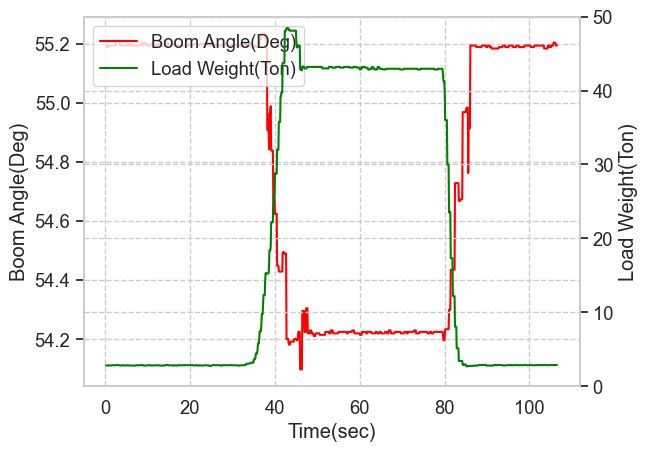

In [195]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

sns.lineplot(data=data_sorted, x='time(sec)', y='boom_angle(deg)', color='red', label='Boom Angle(Deg)', ax=ax1)
sns.lineplot(data=data_sorted, x='time(sec)', y='load_weight(ton)', color='green', label='Load Weight(Ton)', ax=ax2)


lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(lines_1 + lines_2, [labels_1[0], labels_2[0]], loc='upper left')
ax2.get_legend().remove() if ax2.get_legend() else None

ax1.set_ylabel(labels_1[0])
#ax1.set_ylim(43, 45)

ax2.set_ylabel(labels_2[0])
ax2.set_ylim(0, 50)

ax1.set_xlabel('Time(sec)')

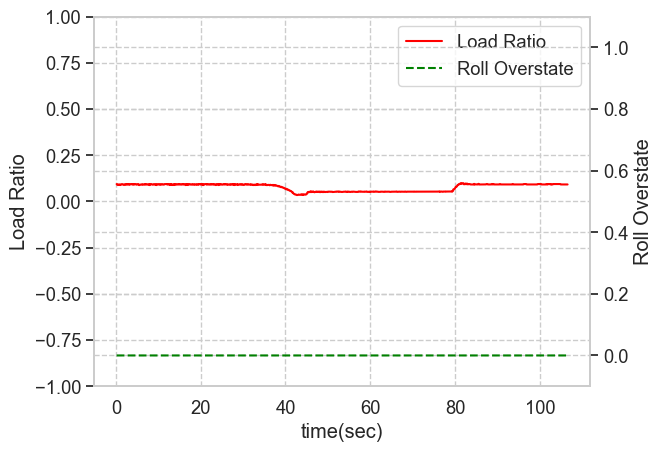

In [179]:
load_cell_name_list = ['load_cell_left_1', 'load_cell_left_2', 'load_cell_left_3',
                       'load_cell_right_1', 'load_cell_right_2', 'load_cell_right_3']
load_cell_name_list = np.array(load_cell_name_list)

sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

left_sum = data_sorted[load_cell_name_list[0]] + data_sorted[load_cell_name_list[2]]
left_1 = data_sorted[load_cell_name_list[0]]/left_sum
left_2 = data_sorted[load_cell_name_list[2]]/left_sum
left = left_1-left_2

right_sum = data_sorted[load_cell_name_list[3]] + data_sorted[load_cell_name_list[5]]
right_1 = data_sorted[load_cell_name_list[3]]/right_sum
right_2 = data_sorted[load_cell_name_list[5]]/right_sum
right = right_1 - right_2

load_ratio = left*right
roll_over_state = (load_ratio < -0.65)*1

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

sns.lineplot(x=data_sorted['time(sec)'], y=load_ratio, color='red', label='Load Ratio', ax=ax1)
sns.lineplot(x=data_sorted['time(sec)'], y=roll_over_state, color='green', linestyle='--', label='Roll Overstate', ax=ax2)

ax1.set_ylim(-1, 1)
ax1.set_ylabel('Load Ratio')
ax2.set_ylim(-0.1, 1.1)
ax2.set_ylabel('Roll Overstate')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(lines_1 + lines_2, [labels_1[0], labels_2[0]], loc='upper right')
ax2.get_legend().remove() if ax2.get_legend() else None

data_sorted['roll_over_state'] = roll_over_state

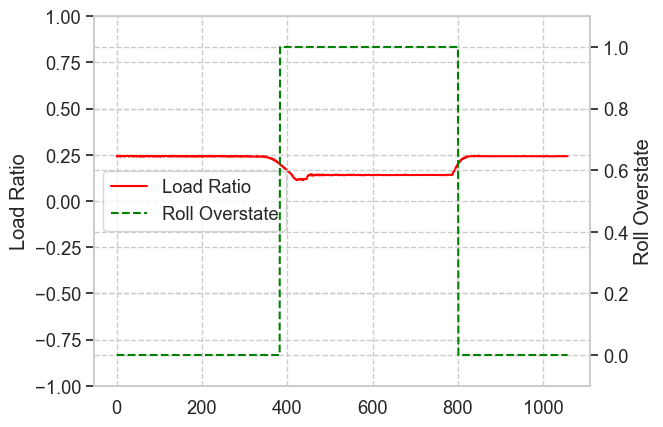

In [196]:
load_cell_name_list = ['load_cell_left_1', 'load_cell_left_2', 'load_cell_left_3',
                       'load_cell_right_1', 'load_cell_right_2', 'load_cell_right_3']
load_cell_name_list = np.array(load_cell_name_list)

sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

left_sum = data_sorted[load_cell_name_list[3]] + data_sorted[load_cell_name_list[0]]
left_1 = data_sorted[load_cell_name_list[3]]/left_sum
left_2 = data_sorted[load_cell_name_list[0]]/left_sum
left = left_1-left_2

right_sum = data_sorted[load_cell_name_list[5]] + data_sorted[load_cell_name_list[2]]
right_1 = data_sorted[load_cell_name_list[5]]/right_sum
right_2 = data_sorted[load_cell_name_list[2]]/right_sum
right = right_1 - right_2

load_ratio = left*right
roll_over_state = (load_ratio < 0.2)*1

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

sns.lineplot(load_ratio, color='red', label='Load Ratio', ax=ax1)
sns.lineplot(roll_over_state, color='green', linestyle='--', label='Roll Overstate', ax=ax2)

ax1.set_ylim(-1, 1)
ax1.set_ylabel('Load Ratio')
ax2.set_ylim(-0.1, 1.1)
ax2.set_ylabel('Roll Overstate')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(lines_1 + lines_2, [labels_1[0], labels_2[0]], loc='center left')
ax2.get_legend().remove() if ax2.get_legend() else None

data_sorted['roll_over_state'] = roll_over_state

Text(0, 0.5, 'Load(Ton)')

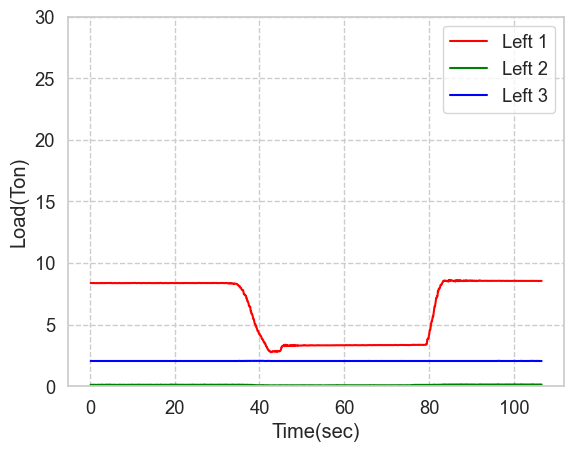

In [197]:
ax2.get_legend().remove() if ax2.get_legend() else None
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

color_name_list = ['red', 'green', 'blue']
load_cell_name_list = ['load_cell_left_1', 'load_cell_left_2', 'load_cell_left_3']
legend_name_list = ['Left 1', 'Left 2', 'Left 3']

for load_cell_name, color_name, legend_name in zip(load_cell_name_list, color_name_list, legend_name_list):
    sns.lineplot(data=data_sorted, x='time(sec)', y=load_cell_name, color=color_name, label=legend_name)

plt.xlabel('Time(sec)')

plt.ylim(0, 30)
plt.ylabel('Load(Ton)')

Text(0, 0.5, 'Load(Ton)')

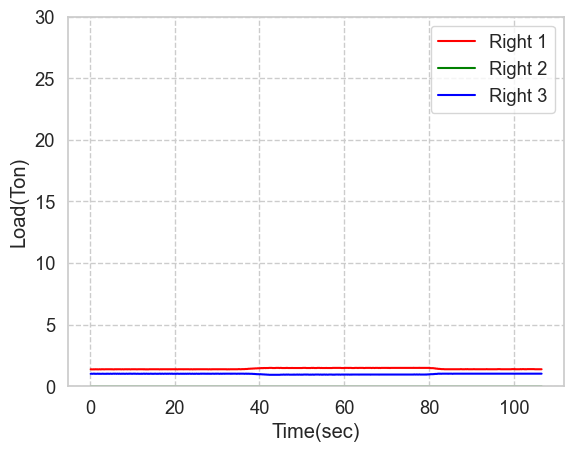

In [198]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

color_name_list = ['red', 'green', 'blue']
load_cell_name_list = ['load_cell_right_1', 'load_cell_right_2', 'load_cell_right_3']
legend_name_list = ['Right 1', 'Right 2', 'Right 3']

for load_cell_name, color_name, legend_name in zip(load_cell_name_list, color_name_list, legend_name_list):
    sns.lineplot(data=data_sorted, x='time(sec)', y=load_cell_name, color=color_name, label=legend_name)

plt.xlabel('Time(sec)')

plt.ylim(0, 30)
plt.ylabel('Load(Ton)')

In [199]:
dataset = data_sorted

feature_name_list = ['boom_angle(deg)', 'ref_swing_angle(deg)', 'load_weight(ton)', 'engine_speed(rpm)',
                     'body_angle_x(deg)', 'body_angle_y(deg)']
target_name = 'roll_over_state'

dataset_df = dataset[feature_name_list + [target_name]]
dataset_df

,boom_angle(deg),ref_swing_angle(deg),load_weight(ton),engine_speed(rpm),body_angle_x(deg),body_angle_y(deg),roll_over_state
0,55.198,90,2.831,748.0,-0.14,0.69,0
1,55.193,90,2.800,748.0,-0.14,0.69,0
2,55.188,90,2.800,748.0,-0.14,0.69,0
3,55.188,90,2.800,748.0,-0.15,0.69,0
4,55.188,90,2.806,748.0,-0.15,0.69,0
...,...,...,...,...,...,...,...
1053,55.203,90,2.856,748.0,-0.14,0.69,0
1054,55.198,90,2.872,748.0,-0.14,0.70,0
1055,55.193,90,2.887,748.0,-0.14,0.70,0
1056,55.193,90,2.887,748.0,-0.14,0.70,0


In [200]:
dataset_arr = dataset_df.to_numpy()

feature = dataset_arr[:, 0:len(feature_name_list)]
target = dataset_arr[:, len(feature_name_list)]

In [201]:
input_buf = np.zeros(shape=(1, seq_len, len(feature_name_list)), dtype=np.float32)
pred_list = []

for input_sig in tqdm(feature):
    input_buf = np.roll(a=input_buf, shift=-1, axis=1)
    input_buf[0, -1, :] = input_sig

    pred_list.append(np.square(model.run(output_names=None, input_feed={'input': input_buf})).item())

pred_arr = np.array(pred_list)

  0%|          | 0/1058 [00:00<?, ?it/s]

In [202]:
target_string = []

for sig in target:
    if sig == 1:
        target_string.append('Unsafe')
    else:
        target_string.append('Safe')

result_df = pd.concat([pd.DataFrame(pred_arr, columns=['prediction']),
                       pd.DataFrame(target_string, columns=['target'])], axis=1)

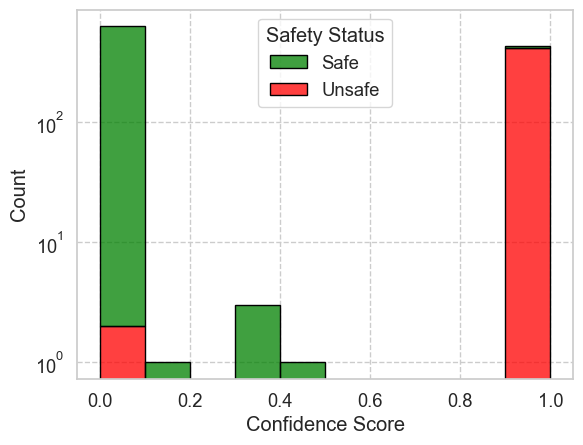

In [203]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

custom_color = {'Unsafe': 'red', 'Safe': 'green'}

ax = sns.histplot(data=result_df, x='prediction', hue='target', bins=10, multiple='stack', edgecolor='black', palette=custom_color)

plt.xlabel('Confidence Score')
plt.yscale('log')

ax.legend_.set_title('Safety Status')

([<matplotlib.axis.YTick at 0x29693cc9b10>,
 [Text(0, 0.5, 'Safe(0)'), Text(0, 1.5, 'Unsafe(1)')])

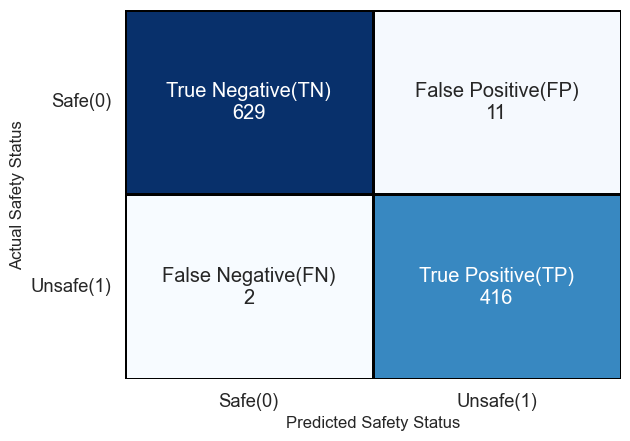

In [204]:
pred_binary = np.where(pred_arr > 0.920, 1, 0)

cm = confusion_matrix(target, pred_binary)

labels = np.array([[f'True Negative(TN)\n{cm[0, 0]}', f'False Positive(FP)\n{cm[0, 1]}'],
                   [f'False Negative(FN)\n{cm[1, 0]}', f'True Positive(TP)\n{cm[1, 1]}']])

sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False, linecolor='black', linewidths=1)

plt.ylabel('Actual Safety Status', fontsize=12)
plt.xlabel('Predicted Safety Status', fontsize=12)

plt.xticks([0.5, 1.5], ['Safe(0)', 'Unsafe(1)'])
plt.yticks([0.5, 1.5], ['Safe(0)', 'Unsafe(1)'], rotation=0, va='center')

Text(0, 0.5, 'Roll Over State')

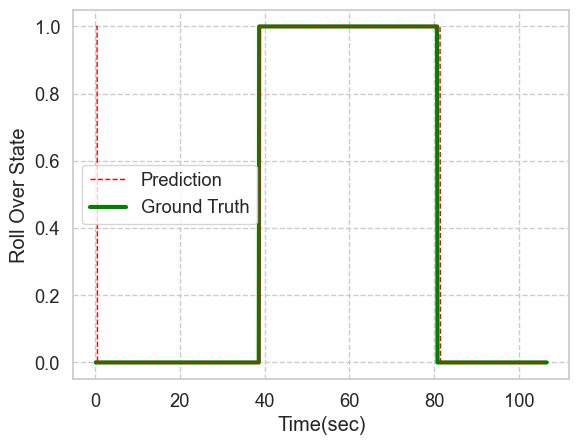

In [205]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

sns.lineplot(x=dataset['time(sec)'], y=pred_binary, color='red', linestyle='--', linewidth=1.0, label='Prediction', zorder=3)
sns.lineplot(data=dataset, x='time(sec)', y='roll_over_state', color='green', linewidth=3, label='Ground Truth', zorder=1)

plt.xlabel('Time(sec)')
plt.ylabel('Roll Over State')


In [206]:
print(f"number of gt unsafe: {np.sum(target == 1)}", f"number of gt safe: {np.sum(target == 0)}")
print(f"number of pred unsafe: {np.sum(pred_binary == 1)}", f"number of pred safe: {np.sum(pred_binary == 0)}")

number of gt unsafe: 418 number of gt safe: 640
number of pred unsafe: 427 number of pred safe: 631


In [207]:
print(precision_score(target, pred_binary, zero_division=0))
print(recall_score(target, pred_binary, zero_division=0))
print(f1_score(target, pred_binary, zero_division=0))
print(accuracy_score(target, pred_binary))

0.9742388758782201
0.9952153110047847
0.9846153846153847
0.9877126654064272
